In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None 

In [4]:
test = pd.read_csv('/kaggle/input/kaggle-llm-science-exam/test.csv')
test.head()

,id,prompt,A,B,C,D,E
0,0,Which of the following statements accurately d...,MOND is a theory that reduces the observed mis...,MOND is a theory that increases the discrepanc...,MOND is a theory that explains the missing bar...,MOND is a theory that reduces the discrepancy ...,MOND is a theory that eliminates the observed ...
1,1,Which of the following is an accurate definiti...,Dynamic scaling refers to the evolution of sel...,Dynamic scaling refers to the non-evolution of...,Dynamic scaling refers to the evolution of sel...,Dynamic scaling refers to the non-evolution of...,Dynamic scaling refers to the evolution of sel...
2,2,Which of the following statements accurately d...,The triskeles symbol was reconstructed as a fe...,The triskeles symbol is a representation of th...,The triskeles symbol is a representation of a ...,The triskeles symbol represents three interloc...,The triskeles symbol is a representation of th...
3,3,What is the significance of regularization in ...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...
4,4,Which of the following statements accurately d...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...


In [5]:
train = pd.read_csv('/kaggle/input/kaggle-llm-science-exam/train.csv')
train.head()

,id,prompt,A,B,C,D,E,answer
0,0,Which of the following statements accurately d...,MOND is a theory that reduces the observed mis...,MOND is a theory that increases the discrepanc...,MOND is a theory that explains the missing bar...,MOND is a theory that reduces the discrepancy ...,MOND is a theory that eliminates the observed ...,D
1,1,Which of the following is an accurate definiti...,Dynamic scaling refers to the evolution of sel...,Dynamic scaling refers to the non-evolution of...,Dynamic scaling refers to the evolution of sel...,Dynamic scaling refers to the non-evolution of...,Dynamic scaling refers to the evolution of sel...,A
2,2,Which of the following statements accurately d...,The triskeles symbol was reconstructed as a fe...,The triskeles symbol is a representation of th...,The triskeles symbol is a representation of a ...,The triskeles symbol represents three interloc...,The triskeles symbol is a representation of th...,A
3,3,What is the significance of regularization in ...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,C
4,4,Which of the following statements accurately d...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,D


In [6]:
combined = pd.concat([train,test])
combined.head()

,id,prompt,A,B,C,D,E,answer
0,0,Which of the following statements accurately d...,MOND is a theory that reduces the observed mis...,MOND is a theory that increases the discrepanc...,MOND is a theory that explains the missing bar...,MOND is a theory that reduces the discrepancy ...,MOND is a theory that eliminates the observed ...,D
1,1,Which of the following is an accurate definiti...,Dynamic scaling refers to the evolution of sel...,Dynamic scaling refers to the non-evolution of...,Dynamic scaling refers to the evolution of sel...,Dynamic scaling refers to the non-evolution of...,Dynamic scaling refers to the evolution of sel...,A
2,2,Which of the following statements accurately d...,The triskeles symbol was reconstructed as a fe...,The triskeles symbol is a representation of th...,The triskeles symbol is a representation of a ...,The triskeles symbol represents three interloc...,The triskeles symbol is a representation of th...,A
3,3,What is the significance of regularization in ...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,C
4,4,Which of the following statements accurately d...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,D


In [7]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 400 entries, 0 to 199
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      400 non-null    int64 
 1   prompt  400 non-null    object
 2   A       400 non-null    object
 3   B       400 non-null    object
 4   C       400 non-null    object
 5   D       400 non-null    object
 6   E       400 non-null    object
 7   answer  200 non-null    object
dtypes: int64(1), object(7)
memory usage: 28.1+ KB


In [8]:
combined.dtypes

id         int64
prompt    object
A         object
B         object
C         object
D         object
E         object
answer    object
dtype: object

In [9]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,400.0,99.5,57.806609,0.0,49.75,99.5,149.25,199.0


In [10]:
combined.columns

Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'], dtype='object')

In [11]:
combined.skew()

/tmp/ipykernel_32/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


id    0.0
dtype: float64

In [12]:
combined.kurt()

/tmp/ipykernel_32/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


id   -1.200046
dtype: float64

In [13]:
combined.isnull().sum()/len(combined)*100

id         0.0
prompt     0.0
A          0.0
B          0.0
C          0.0
D          0.0
E          0.0
answer    50.0
dtype: float64

In [14]:
combined.shape

(400, 8)

In [15]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

id    99.5
dtype: float64


/tmp/ipykernel_32/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_32/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_32/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [16]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [17]:
combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]

/tmp/ipykernel_32/1567334620.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]


In [18]:
combined_new.shape

(0, 8)

<Axes: >

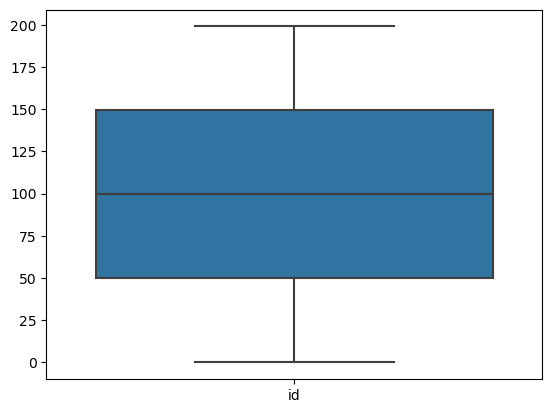

In [19]:
sns.boxplot(combined)

<Axes: >

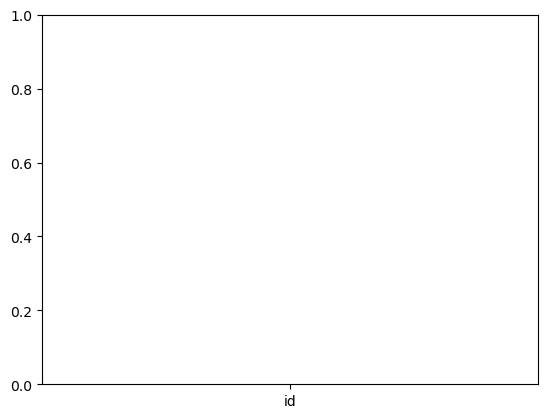

In [43]:
sns.violinplot(combined)

<Axes: >

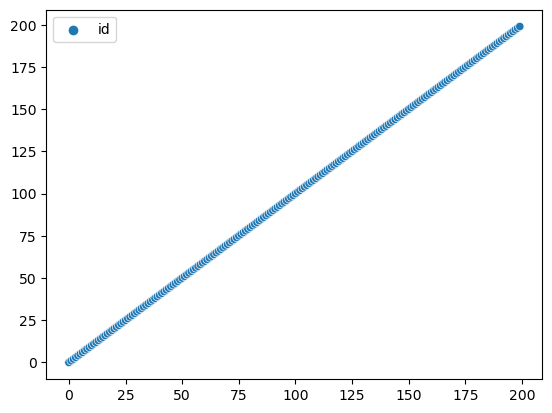

In [20]:
sns.scatterplot(combined)

<Axes: >

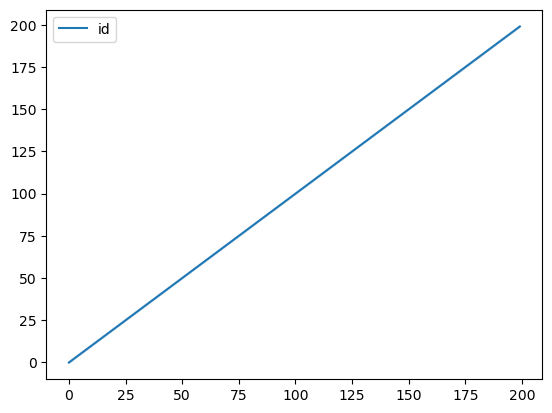

In [21]:
sns.lineplot(combined)

<Axes: >

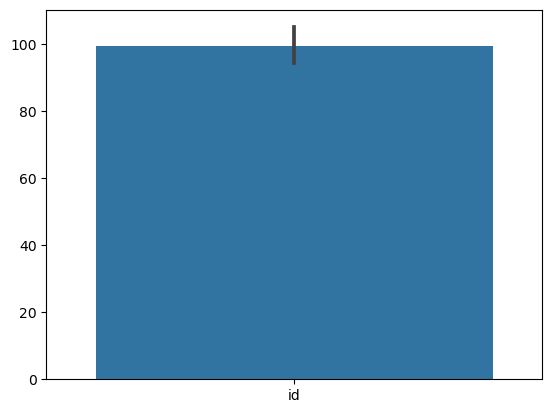

In [22]:
sns.barplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


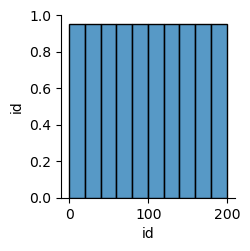

In [23]:
sns.pairplot(combined)

/tmp/ipykernel_32/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

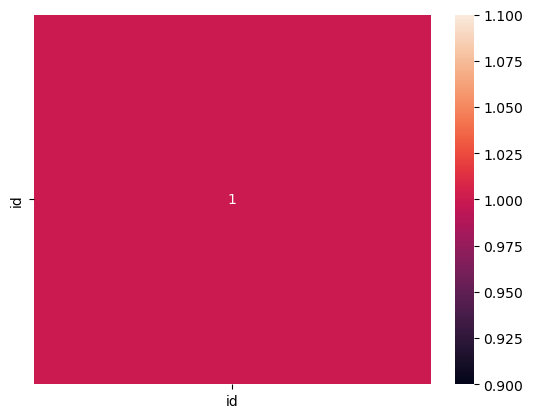

In [24]:
sns.heatmap(combined.corr(),annot=True)

<Axes: ylabel='Density'>

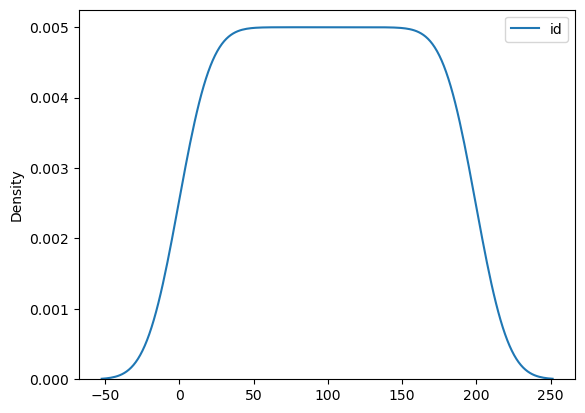

In [25]:
sns.kdeplot(combined)

<Axes: ylabel='count'>

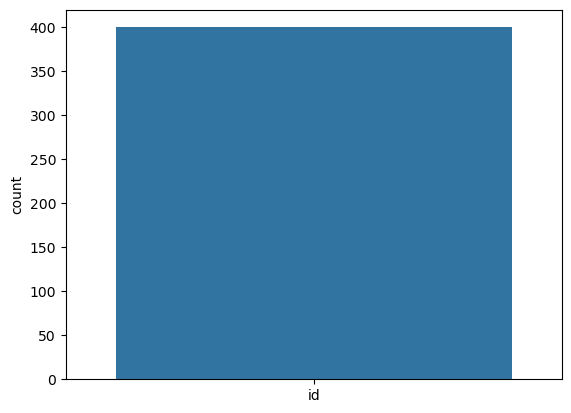

In [44]:
sns.countplot(combined)

In [26]:
cat_cols = combined.select_dtypes(include='object')

In [29]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print(''*50)

prompt
Which of the following statements accurately describes the impact of Modified Newtonian Dynamics (MOND) on the observed "missing baryonic mass" discrepancy in galaxy clusters?    2
What is the main focus of the Environmental Science Center at Qatar University?                                                                                                    2
What is the De Haas-Van Alphen effect?                                                                                                                                             2
What is a "coffee ring" in physics?                                                                                                                                                2
What is the significance of probability amplitudes in quantum mechanics?                                                                                                           2
                                                                                        

In [30]:
num_cols = combined.select_dtypes(include='number')

In [31]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print(''*50)

id
0      2
137    2
127    2
128    2
129    2
      ..
69     2
70     2
71     2
72     2
199    2
Name: id, Length: 200, dtype: int64



In [32]:
combined['id']=combined['id'].map({"Good":2,'Standard':1,'Poor':0})

/tmp/ipykernel_32/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


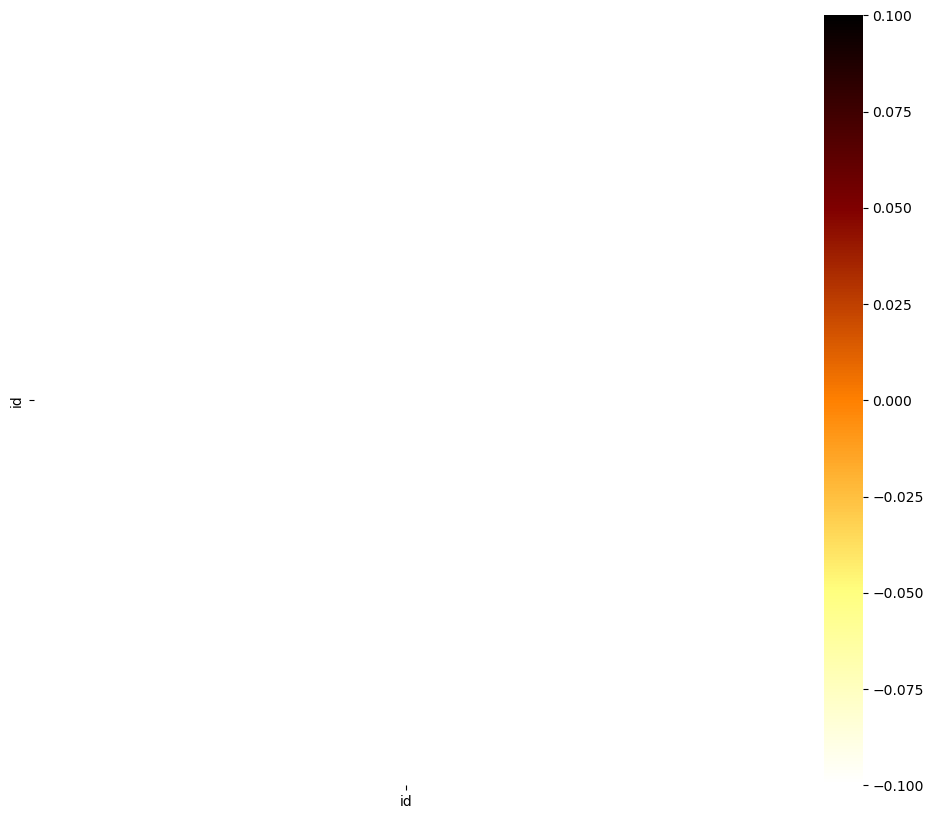

In [33]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


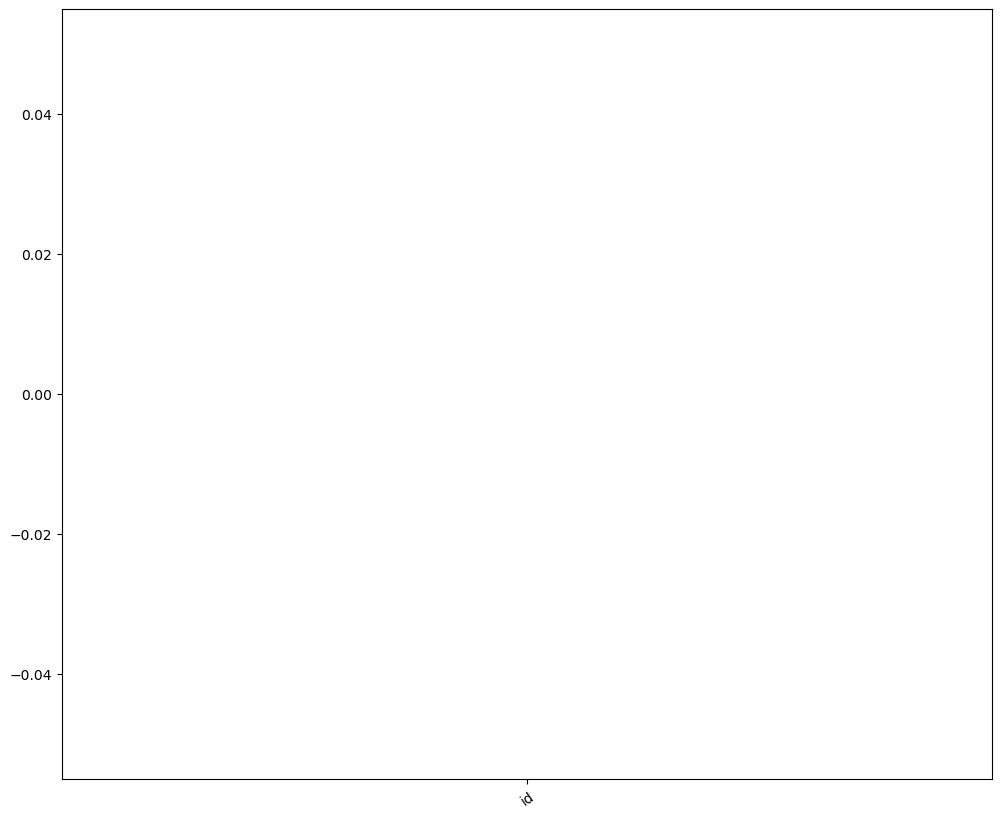

In [34]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=35);

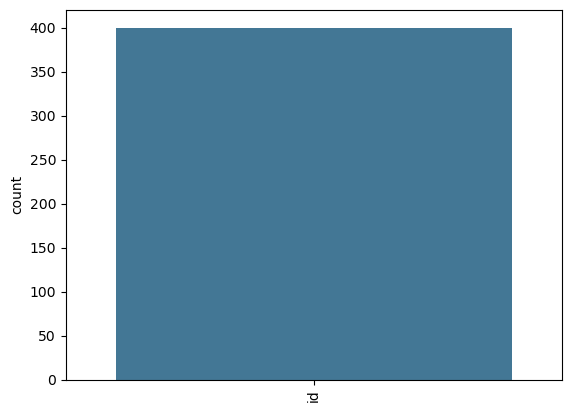

In [35]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90);

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


(array([0]), [Text(0, 0, 'id')])

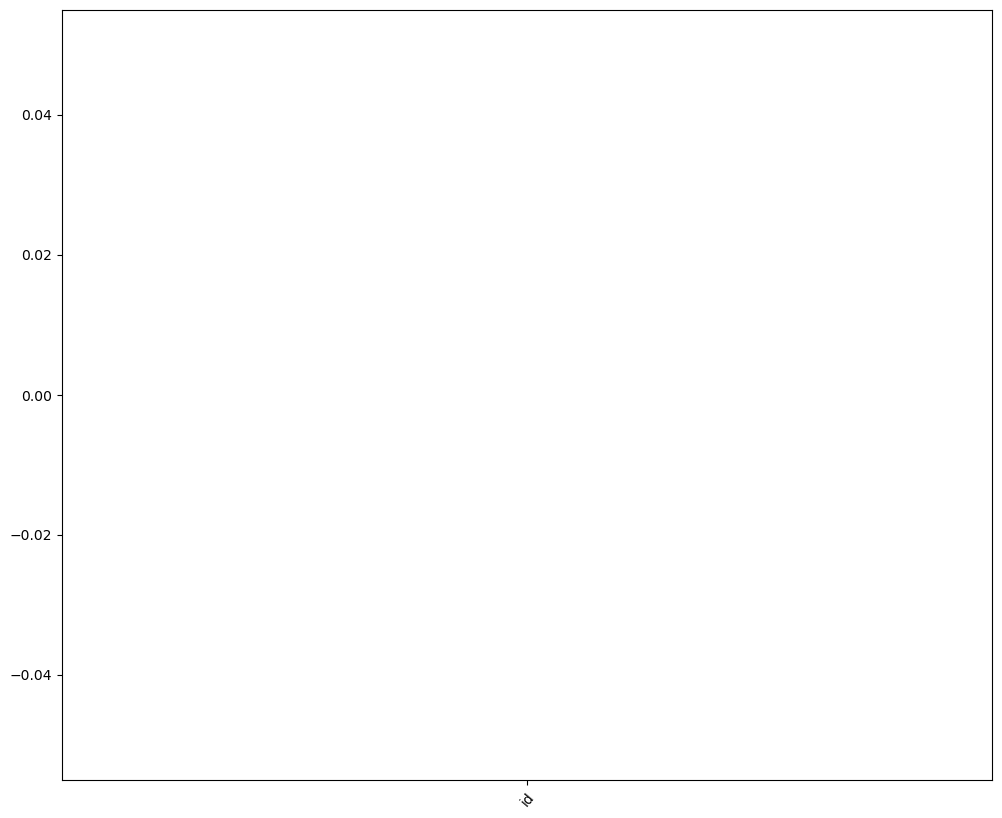

In [36]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako')
plt.xticks(rotation=50)

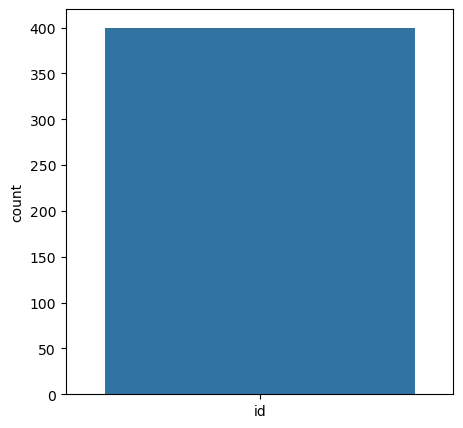

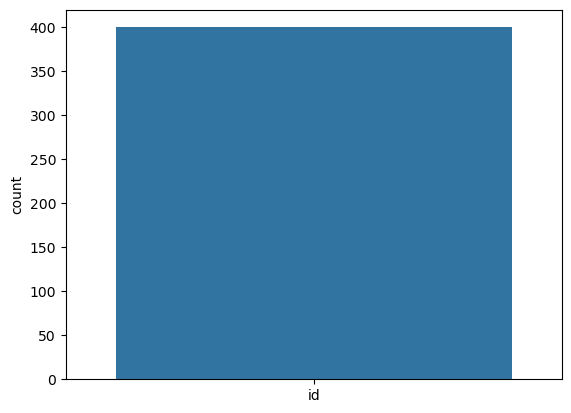

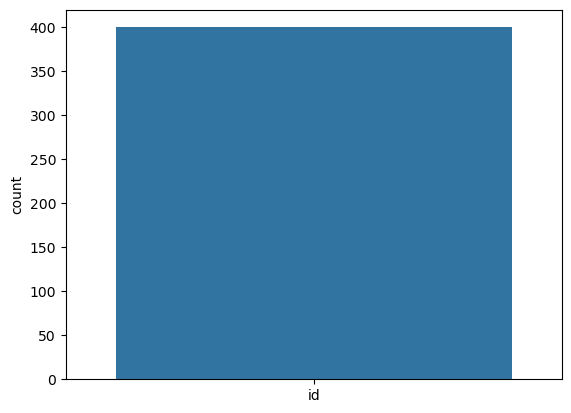

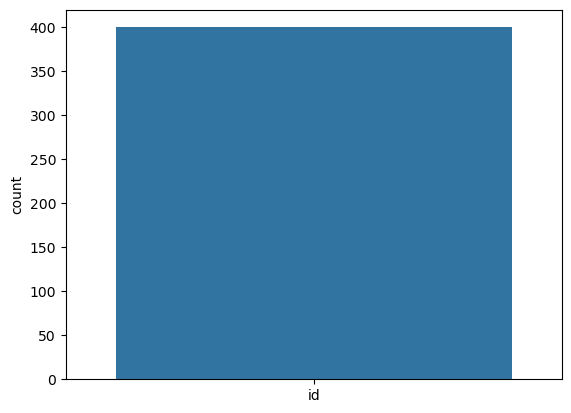

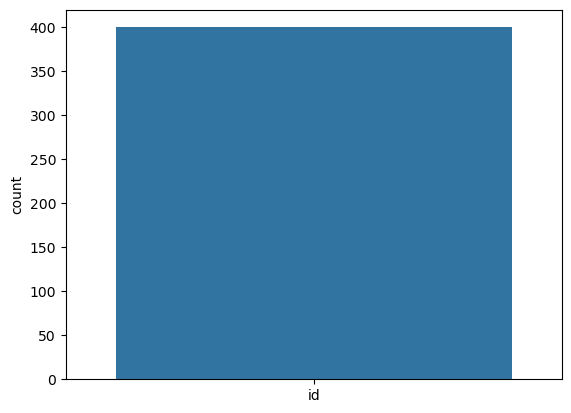

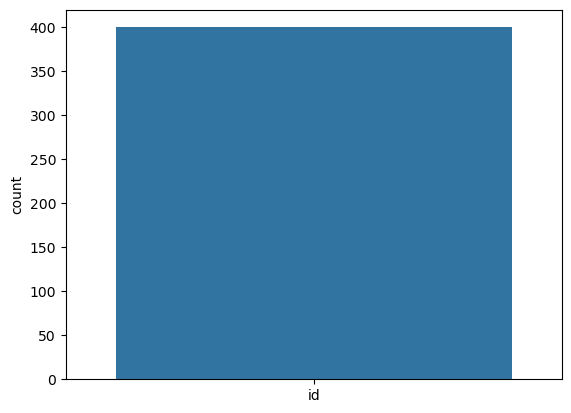

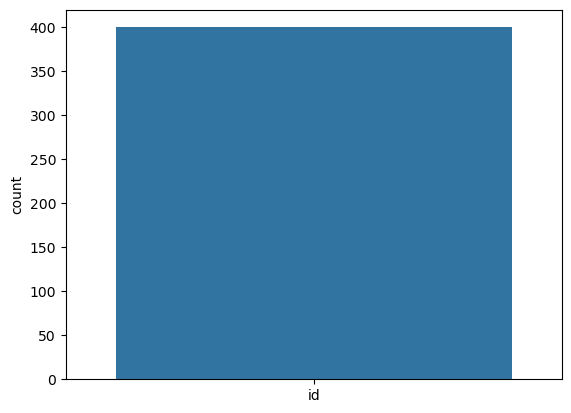

In [37]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    sns.countplot(data=combined)
    print('\n')
    plt.show()

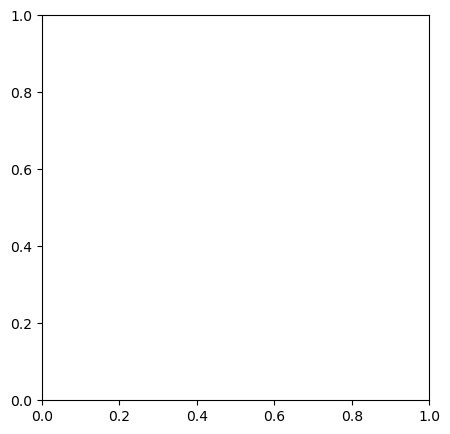

In [45]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.kdeplot(data=combined,x=i)
    print('\n')
    plt.show()

In [39]:
combined['id'].value_counts()

Series([], Name: id, dtype: int64)

In [40]:
combined['id'].unique()

array([nan])

In [41]:
combined['id'].append

<bound method Series.append of 0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
195   NaN
196   NaN
197   NaN
198   NaN
199   NaN
Name: id, Length: 400, dtype: float64>

In [46]:
combined.head()

,id,prompt,A,B,C,D,E,answer
0,NaN,Which of the following statements accurately d...,MOND is a theory that reduces the observed mis...,MOND is a theory that increases the discrepanc...,MOND is a theory that explains the missing bar...,MOND is a theory that reduces the discrepancy ...,MOND is a theory that eliminates the observed ...,D
1,NaN,Which of the following is an accurate definiti...,Dynamic scaling refers to the evolution of sel...,Dynamic scaling refers to the non-evolution of...,Dynamic scaling refers to the evolution of sel...,Dynamic scaling refers to the non-evolution of...,Dynamic scaling refers to the evolution of sel...,A
2,NaN,Which of the following statements accurately d...,The triskeles symbol was reconstructed as a fe...,The triskeles symbol is a representation of th...,The triskeles symbol is a representation of a ...,The triskeles symbol represents three interloc...,The triskeles symbol is a representation of th...,A
3,NaN,What is the significance of regularization in ...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,Regularizing the mass-energy of an electron wi...,C
4,NaN,Which of the following statements accurately d...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,The angular spacing of features in the diffrac...,D


In [47]:
x = combined[['id']]

In [48]:
y = combined [['id']]

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [52]:
from sklearn.linear_model import LinearRegression

In [55]:
lr = LinearRegression()

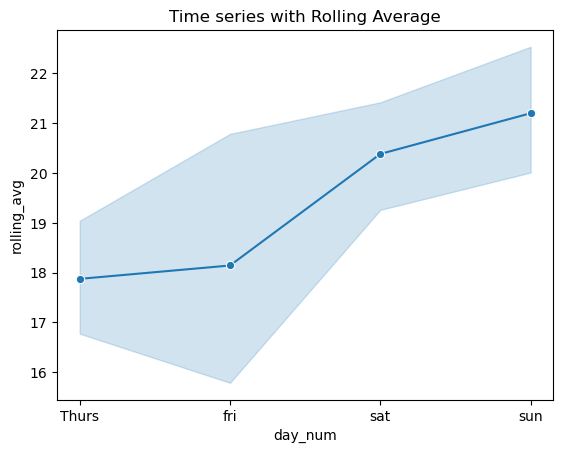

In [56]:
df_tips = sns.load_dataset('tips')
df_tips['day_num']= df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg',data=df_tips,marker='o')
plt.xticks(ticks=[0,1,2,3],labels=['Thurs','fri','sat','sun'])
plt.title("Time series with Rolling Average")
plt.show()